In [1]:
import tracemalloc

import matplotlib.pyplot as plt
import pandas as pd
import pyspark.sql.functions as F
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.window import Window

In [41]:
!pip install memory_profiler
%load_ext memory_profiler

In [2]:
!pip install pyspark

In [3]:
#spark = SparkSession.builder \
 # .appName("ColabAnalysis") \
 # .master("local[*]") \
 # .getOrCreate()

spark = (
    SparkSession.builder
    .appName("ClinicalAnalysis")
    .master("local[*]")
    .config("spark.driver.memory", "4g") # Give Java 4GB RAM
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

In [4]:
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

In [5]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/doctorado/ciencia de datos

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/doctorado/ciencia de datos


In [6]:
full = pd.read_pickle("full.pkl")

In [7]:
full = full.reset_index(drop=True)

for col in full.select_dtypes(include=['datetime', 'datetime64']).columns:
  full[col] = full[col].astype('datetime64[us]')

for col in full.select_dtypes(include=['category']).columns:
  full[col] = full[col].astype(str)

full_spark = spark.createDataFrame(full) # esto tardo 40s

In [8]:
full_spark.show(5)

+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------+---------+--------------------+-------------------+----------------+--------------+-----------+-----------------+-------------------+--------+--------------------+-------+-------+-----------+-------------------+---------+---------+-----+-----------+------+--------------------+---------+---------+-------------------+-------------------+------+
|           encounter|              start|               stop|             patient|        organization|            provider|               payer|encounterclass| enc_code|            enc_desc|base_encounter_cost|total_claim_cost|payer_coverage| reasoncode|reasondescription|               date|obs_code|            obs_desc|  units|num_val|non_num_val|          birthdate|deathdate|      ssn| race|  ethnicity|gender|          birthplace|      lat|      lon|healthcare_expenses|healthcare_cover

In [9]:
full_spark.printSchema()

root
 |-- encounter: string (nullable = true)
 |-- start: timestamp (nullable = true)
 |-- stop: timestamp (nullable = true)
 |-- patient: string (nullable = true)
 |-- organization: string (nullable = true)
 |-- provider: string (nullable = true)
 |-- payer: string (nullable = true)
 |-- encounterclass: string (nullable = true)
 |-- enc_code: string (nullable = true)
 |-- enc_desc: string (nullable = true)
 |-- base_encounter_cost: float (nullable = true)
 |-- total_claim_cost: float (nullable = true)
 |-- payer_coverage: float (nullable = true)
 |-- reasoncode: double (nullable = true)
 |-- reasondescription: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- obs_code: string (nullable = true)
 |-- obs_desc: string (nullable = true)
 |-- units: string (nullable = true)
 |-- num_val: float (nullable = true)
 |-- non_num_val: string (nullable = true)
 |-- birthdate: timestamp (nullable = true)
 |-- deathdate: timestamp (nullable = true)
 |-- ssn: integer (nullable = t

In [10]:
def clinical_one_spark(df):
  uno = (df
         .select('patient', 'gender', 'ethnicity')
         .dropDuplicates(subset=['patient'])
         .groupBy('gender', 'ethnicity')
         .count()
         .orderBy('gender', 'ethnicity')
    )
  return uno

In [20]:
tracemalloc.start()
test = clinical_one_spark(full_spark).collect()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"current: {current / 10**6:.2f}\tpeak: {peak / 10**6:.2f} MB")

current: 0.03	peak: 0.17 MB


Creo que aqui me quede sin ram, al intentar correr esa funcion me salia este error: # ConnectionRefusedError: [Errno 111] Connection refused

Tuve que reiniciar la sesion y asignarle mas ram a java para poder avanzar

In [16]:
test # mismo resultado, colab dice que le tomo 22 segundos

[Row(gender='F', ethnicity='hispanic', count=675),
 Row(gender='F', ethnicity='nonhispanic', count=5575),
 Row(gender='M', ethnicity='hispanic', count=640),
 Row(gender='M', ethnicity='nonhispanic', count=5440)]

In [42]:
%%memit
test = clinical_one_spark(full_spark).collect()

peak memory: 2191.57 MiB, increment: 0.05 MiB


In [18]:
def clinical_two_spark(df):
  patient_encounters = (df
                        .select('patient', 'encounter', 'gender')
                        .dropDuplicates(subset=['encounter'])
                        .groupBy('patient', 'gender')
                        .agg(F.count('encounter').alias('count'))
                        )
  metrics = (patient_encounters
             .groupBy('gender')
             .agg(F.avg('count').cast('double').alias('Mean'),
                  F.percentile_approx('count', 0.5).cast('double').alias('Median'))
             )
  dos = metrics.select('gender', F.expr("stack(2, 'Mean', Mean, 'Median', Median) as (metric, value)"))
  return dos

In [21]:
tracemalloc.start() # colab dice 24s
test = clinical_two_spark(full_spark).collect()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"current: {current / 10**6:.2f}\tpeak: {peak / 10**6:.2f} MB")

current: 0.02	peak: 0.16 MB


In [24]:
test # mismo resultado

[Row(gender='F', metric='Mean', value=24.38288),
 Row(gender='F', metric='Median', value=11.0),
 Row(gender='M', metric='Mean', value=27.81825657894737),
 Row(gender='M', metric='Median', value=9.0)]

In [43]:
%%memit
test = clinical_two_spark(full_spark).collect()

peak memory: 2191.57 MiB, increment: 0.00 MiB


In [35]:
def clinical_three_spark(df, n):
  cols = ['gender', 'obs_code', 'obs_desc']
  nonans = (df # spark tiene su propio tipo de nan (null) y algunos nans los puede estar leyendo como strings, debo convertirlos manualmente
            .filter(F.col('obs_code').isNotNull() & (~F.lower(F.col('obs_code')).isin('nan', 'none', 'null', '')))
            )
  counts_df = (nonans.
               select(cols)
               .groupBy(cols)
               .count()
  )
  window = Window.partitionBy('gender').orderBy(F.col('count').desc())
  tres = (counts_df
          .withColumn('rank', F.row_number().over(window))
          .filter(F.col('rank') <= n)
          .drop('rank')
          .orderBy('gender', F.col('count').desc())
          )
  return tres

In [36]:
tracemalloc.start() # colab dice 13s
test = clinical_three_spark(full_spark, 10).collect()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"current: {current / 10**6:.2f}\tpeak: {peak / 10**6:.2f} MB")

current: 0.09	peak: 0.22 MB


In [37]:
test

[Row(gender='F', obs_code='8462-4', obs_desc='Diastolic Blood Pressure', count=24440),
 Row(gender='F', obs_code='8480-6', obs_desc='Systolic Blood Pressure', count=24440),
 Row(gender='F', obs_code='29463-7', obs_desc='Body Weight', count=23912),
 Row(gender='F', obs_code='8867-4', obs_desc='Heart rate', count=23912),
 Row(gender='F', obs_code='9279-1', obs_desc='Respiratory rate', count=23912),
 Row(gender='F', obs_code='2708-6', obs_desc='Oxygen saturation in Arterial blood', count=22645),
 Row(gender='F', obs_code='8310-5', obs_desc='Body temperature', count=19016),
 Row(gender='F', obs_code='718-7', obs_desc='Hemoglobin [Mass/volume] in Blood', count=13562),
 Row(gender='F', obs_code='787-2', obs_desc='MCV [Entitic volume] by Automated count', count=13556),
 Row(gender='F', obs_code='786-4', obs_desc='MCHC [Mass/volume] by Automated count', count=13556),
 Row(gender='M', obs_code='8462-4', obs_desc='Diastolic Blood Pressure', count=23692),
 Row(gender='M', obs_code='8480-6', obs_d

In [44]:
%%memit
test = clinical_three_spark(full_spark, 10).collect()

peak memory: 2191.57 MiB, increment: 0.00 MiB


In [30]:
def clinical_four_spark(df):
  cuatro_spark = (df
                  .filter(F.col('obs_code') == '718-7')
                  .select('patient', 'gender', 'num_val')
                  .dropna(subset=['num_val'])
                  )
  cuatro_pd = cuatro_spark.toPandas() # para la grafica porque no encontre como graficar con los objetos de spark
  cuatro = (cuatro_spark.
            groupBy('patient', 'gender')
            .agg(F.count('*').alias('obs_count'))
            .filter(F.col('obs_count') >= 3)
            .groupBy('gender')
            .agg(F.count('*').alias('patient_count'))
            )
  cuatro_summary = cuatro.toPandas()
  count_map = dict(zip(cuatro_summary['gender'], cuatro_summary['patient_count']))
  f_count = count_map.get('F', 0)
  m_count = count_map.get('M', 0)
  _fig, axs = plt.subplots(2, 1, figsize=(7, 4))
  colors = ('#1B998B', '#274C77')
  for i, gender in enumerate(('F', 'M')):
    ax = axs[i]
    data = cuatro_pd[cuatro_pd['gender'] == gender]
    if not data.empty:
      sns.histplot(data['num_val'],
                   ax=ax,
                   bins=40,
                   fill=False,
                   color=colors[i],
                   label='Female' if i == 0 else 'Male',
                   legend=True)
      ax.legend(loc='upper left', frameon=True)
  axs[0].set_title('Distribution of Hemoglobin in blood of patients')
  axs[1].set_xlabel('g/dL')
  axs[0].text(1.01, 0.5, f'* # of patients with at least\n3 measurements:\n\n* {f_count}', transform=axs[0].transAxes)
  axs[0].text(1.01, -0.5, f'* {m_count}', transform=axs[0].transAxes)
  return cuatro

current: 2.71	peak: 4.15 MB


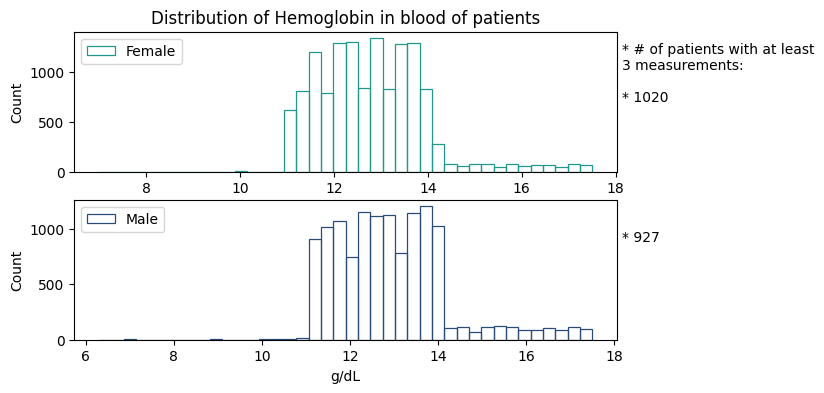

In [31]:
tracemalloc.start() # colab dice 14s
test = clinical_four_spark(full_spark).collect()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"current: {current / 10**6:.2f}\tpeak: {peak / 10**6:.2f} MB")

In [32]:
test # mismo resultado

[Row(gender='F', patient_count=1020), Row(gender='M', patient_count=927)]

peak memory: 2191.57 MiB, increment: 0.00 MiB


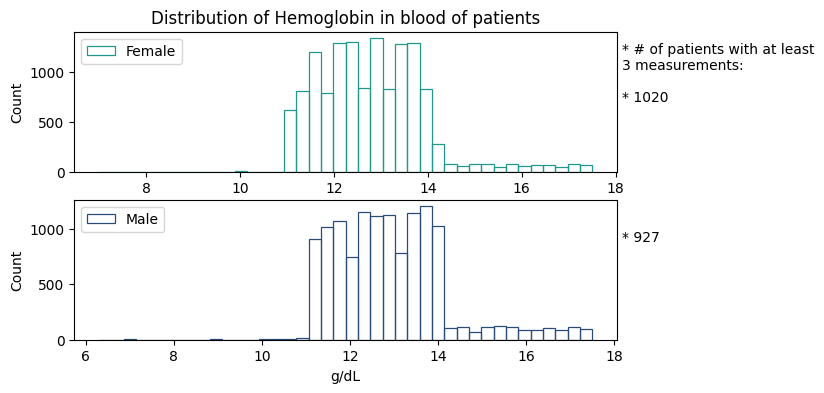

In [45]:
%%memit
test = clinical_four_spark(full_spark).collect()

In [39]:
%%timeit
test1 = clinical_one_spark(full_spark).collect()
test2 = clinical_two_spark(full_spark).collect()
test3 = clinical_three_spark(full_spark, 10).collect()
test4 = clinical_four_spark(full_spark).collect()
plt.close()

27.8 s ± 637 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
